# 01 Risk Free Data

Run after 01_Stock_Data. This module freezes the rate and benchmark conventions used by all subsequent modules.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [2]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json

cfg = load_config()


Module 01_rf | jupyter_v2_01


## 2. Load frozen rates and benchmark

Rates are treated as annual-effective decimals. The default benchmark is the S&P 500 price index, not SPY or a total-return index.


In [3]:
from scripts.run_research import read_series
risk_free_rates = read_series(OUTPUT_DIR / 'inputs/rates.parquet')
benchmark = read_series(OUTPUT_DIR / 'inputs/benchmark.parquet')
if (risk_free_rates <= -1).any():
    raise ValueError('Annual-effective decimal rates must be greater than -1.')
display(risk_free_rates.describe())
display(benchmark.head())


count    2513.000000
mean        0.021571
std         0.018862
min        -0.001050
25%         0.002950
50%         0.017130
75%         0.041930
max         0.053480
Name: risk_free_rate, dtype: float64

Date
2022-12-28    3783.219971
2022-12-29    3849.280029
2022-12-30    3839.500000
2023-01-03    3824.139893
2023-01-04    3852.969971
Name: sp500, dtype: float64

## 3. Verify coverage and save

Check coverage before expensive pair screening. The same prior-session daily rate conversion is used later in Modules 09 and 12.


,market_return,rf_daily
Date,,
2022-12-29,0.017461,0.000169
2022-12-30,-0.002541,0.000167
2023-01-03,-0.004001,0.000166
2023-01-04,0.007539,0.000165
2023-01-05,-0.011646,0.000171


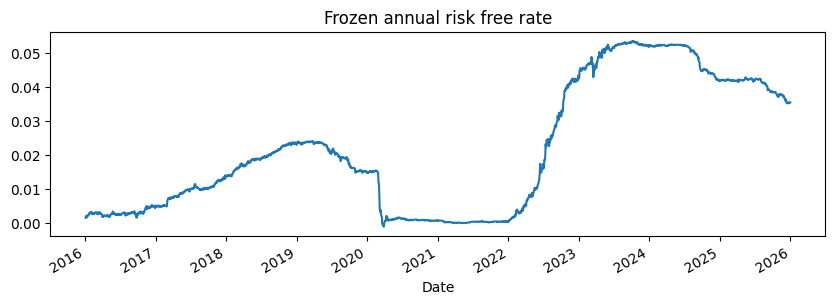

In [4]:
from src.research_validation import aligned_returns
test_prices = load_frame('test_prices')
coverage = aligned_returns(pd.DataFrame({'equity': cfg.initial_capital}, index=test_prices.index), benchmark, risk_free_rates)
save_frame('risk_free_rates', risk_free_rates.to_frame('risk_free_rate'))
save_frame('benchmark_prices', benchmark.to_frame('benchmark'))
display(coverage[['market_return', 'rf_daily']].head())
risk_free_rates.plot(figsize=(10, 3), title='Frozen annual risk free rate')
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [5]:
print(f'Completed. Files saved in {OUTPUT_DIR}')


Completed 01_rf. Outputs saved in C:\Users\Iván\anaconda_projects\84fb5a87-072e-47a3-b69f-e9690ffef909\runs\jupyter_v2_01
